In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
from pathlib import Path
import glob

project_root = Path.cwd().parent
sys.path.append(str(project_root))

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

# Experimental conditions

In [40]:
plt.rcParams.update({
    "text.usetex": True,

    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],

    "ytick.color": "black",
    "xtick.color": "black",
    "axes.labelcolor": "black",
    "axes.edgecolor": "black",

    "axes.linewidth": 0.8,

    "xtick.direction": "in",
    "ytick.direction": "in",
})

In [4]:
silver_path = Path.cwd().parent / 'data/silver_layer/'

In [5]:
silver_path = Path.cwd().parent / 'data/silver_layer/'

silver_confocal_path = Path.cwd().parent / 'data/silver_layer/confocal_runs'
gold_profile_path = Path.cwd().parent / 'data/gold_layer/profile_pics'

In [6]:

df_confocal = pd.read_pickle(silver_path / 'confocal_results.pkl')
df_experimental = pd.read_pickle(silver_path / 'experimental_results.pkl')

In [7]:
missing_threshold = 50

In [8]:
df_consolidated = pd.merge(df_confocal.loc[df_confocal['t2_missing_percentage']<missing_threshold, 'run_id'], df_experimental, on='run_id', how='inner')

In [9]:
df = df_consolidated.copy()

In [10]:
jg = pd.Series([0.1049, 1.6286, 0.7571, 2.6015, 4.2504, 17.8180, 13.3123, 6.5641, 16.2489, 98.3638])
jl = pd.Series([0.7245, 1.2322, 6.0739, 1.2651, 0.0354, 1.1254, 0.0915, 0.0397, 0.0410, 1.0334])

In [ ]:
CM = 1 / 2.54

FIG_WIDTH_CM = 8.4
FIG_HEIGHT_CM = FIG_WIDTH_CM * (7.62 / 10.9)
FIG_SIZE = (FIG_WIDTH_CM * CM, FIG_HEIGHT_CM * CM)

In [26]:
PLOT_STYLE = {

    # Lines
    "line_color": "k",
    "line_width": 0.7,

    # Scatter
    "marker_size": 30,
    "marker_edgecolor": "k",
    "marker_linewidth": 0.5,

    # Grid
    "grid_alpha": 0.5,
}


In [11]:
# =========================================================
# Flow pattern boundaries
# =========================================================

connections = [
    (0, 1),
    (1, 2),
    (1, 3),
    (3, 4),
    (3, 5),
    (5, 6),
    (6, 7),
    (6, 8),
    (5, 9),
]

In [ ]:
# params = {"ytick.color" : "black",
#           "xtick.color" : "black",
#           "axes.labelcolor" : "black",
#           "axes.edgecolor" : "black",
#           "text.usetex" : True,
#           "font.family" : "serif",
#           "font.serif" : ["Computer Modern Serif"]}
# plt.rcParams.update(params)
# cm = 1/2.54

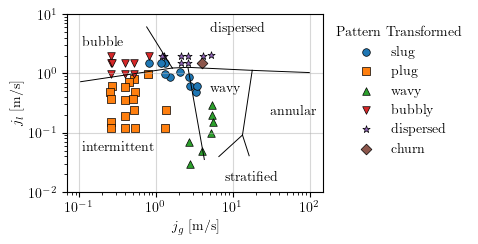

In [ ]:
# =========================================================
# Figure
# =========================================================

fig, ax = plt.subplots(figsize=FIG_SIZE)

# =========================================================
# Boundary lines
# =========================================================

for i, j in connections:

    ax.plot(
        [jg[i], jg[j]],
        [jl[i], jl[j]],
        color=PLOT_STYLE["line_color"],
        linewidth=PLOT_STYLE["line_width"]
    )

# =========================================================
# Scatter points
# =========================================================

unique_categories = df["reduced_pattern"].unique()

markers = ['o', 's', '^', 'v', '*', 'D', 'X', 'P']

markers_mapping = {
    category: marker
    for category, marker in zip(unique_categories, markers)
}

for category in unique_categories:

    subset = df[df["reduced_pattern"] == category]

    ax.scatter(
        subset["jg"],
        subset["jl"],

        s=PLOT_STYLE["marker_size"],

        edgecolor=PLOT_STYLE["marker_edgecolor"],
        linewidth=PLOT_STYLE["marker_linewidth"],

        marker=markers_mapping[category],

        label=category
    )

# =========================================================
# Labels
# =========================================================

ax.text(1.1e-1, 3, "bubble")
ax.text(8, 1.5e-2, "stratified")
ax.text(1.1e-1, 5e-2, "intermittent")
ax.text(5, 5, "dispersed")
ax.text(5, 0.5, "wavy")
ax.text(30, 0.2, "annular")

# =========================================================
# Axes
# =========================================================

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlim([0.07, 150])
ax.set_ylim([0.01, 10])

ax.grid(alpha=PLOT_STYLE["grid_alpha"])

ax.set_xlabel(r"$j_g\;$[m/s]")
ax.set_ylabel(r"$j_l\;$[m/s]")


ax.legend(title="Pattern Transformed", bbox_to_anchor=(1, 1), loc="upper left", frameon=False)

# =========================================================
# Optional save
# =========================================================

# plt.savefig("figures/pattern_map.eps")

plt.show()

In [ ]:
# # Create figure and axes
# f, ax = plt.subplots(figsize=(10.9 * cm, 7.62 * cm))

# # Example markers for each category
# unique_categories = df['reduced_pattern'].unique()
# markers_mapping = {category: marker for category, marker in zip(unique_categories, ['o', 's', '^', 'v', '*', 'D', 'X', 'P'])}

# plt.xlim([0.07, 150])
# plt.ylim([0.01, 10])
# plt.grid(alpha=0.5)

# ax.plot([jg[0], jg[1]], [jl[0], jl[1]], color='k')
# ax.plot([jg[1], jg[2]], [jl[1], jl[2]], color='k')
# ax.plot([jg[1], jg[3]], [jl[1], jl[3]], color='k')
# ax.plot([jg[3], jg[4]], [jl[3], jl[4]], color='k')
# ax.plot([jg[3], jg[5]], [jl[3], jl[5]], color='k')
# ax.plot([jg[5], jg[6]], [jl[5], jl[6]], color='k')
# ax.plot([jg[6], jg[7]], [jl[6], jl[7]], color='k')
# ax.plot([jg[6], jg[8]], [jl[6], jl[8]], color='k')
# ax.plot([jg[5], jg[9]], [jl[5], jl[9]], color='k')

# # Custom scatterplot with multiple markers
# for category in unique_categories:
#     subset = df[df['reduced_pattern'] == category]
#     ax.scatter(
#         x=subset['jg'],
#         y=subset['jl'],
#         s=30,
#         edgecolor='k',
#         linewidth=0.5,
#         marker=markers_mapping[category],
#         label=category
#     )

# # Set log scales for axes
# ax.set_xscale('log')
# ax.set_yscale('log')

# # ax.grid(True, which="both", linestyle='--', linewidth=0.5)
# ax.set_xlabel(r'$j_g\;$[m/s]', fontsize=12)
# ax.set_ylabel(r'$j_l\;$[m/s]', fontsize=12)
# ax.tick_params(axis="both", which="both", direction="in")

# # Legend configuration
# ax.legend(title="Pattern Transformed", bbox_to_anchor=(1, 1), loc="upper left", frameon=False)

# # Optional save
# # plt.savefig('figures/pattern_map2.eps', format='eps', bbox_inches='tight')

# plt.show()